In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os

print("OpenCV version:", cv2.__version__)

OpenCV version: 5.0.0


In [3]:
dataset_path = r"D:\ComputerVisionBenchmark\datasets\rgb"
image_files = sorted(glob.glob(os.path.join(dataset_path, "*.png")))
print("Total images:", len(image_files))

Total images: 613


In [4]:
orb = cv2.ORB_create(nfeatures=1500)

all_kp_orb = []
all_des_orb = []

for f in image_files:
    img = cv2.imread(f)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kp, des = orb.detectAndCompute(gray, None)
    all_kp_orb.append(kp)
    all_des_orb.append(des)

print("Extracted ORB features for", len(all_kp_orb), "images")

Extracted ORB features for 613 images


In [5]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING)

results_orb = []

for i in range(len(image_files) - 1):
    kp1, des1 = all_kp_orb[i], all_des_orb[i]
    kp2, des2 = all_kp_orb[i + 1], all_des_orb[i + 1]

    if des1 is None or des2 is None or len(des1) < 2 or len(des2) < 2:
        results_orb.append((i, i + 1, 0, 0))
        continue

    matches = bf.knnMatch(des1, des2, k=2)

    good_matches = []
    for match_pair in matches:
        if len(match_pair) == 2:
            m, n = match_pair
            if m.distance < 0.75 * n.distance:
                good_matches.append(m)

    if len(good_matches) < 4:
        results_orb.append((i, i + 1, len(good_matches), 0))
        continue

    pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches])

    H, mask = cv2.findHomography(pts1, pts2, cv2.RANSAC, 5.0)
    inliers = int(mask.ravel().sum()) if mask is not None else 0

    results_orb.append((i, i + 1, len(good_matches), inliers))

print("Total consecutive pairs processed:", len(results_orb))

Total consecutive pairs processed: 612


   Frame_n  Frame_n+1  Matches  Inliers  Inlier_Ratio
0        0          1      619      565      0.912763
1        1          2      654      621      0.949541
2        2          3      648      607      0.936728
3        3          4      655      610      0.931298
4        4          5      781      731      0.935980
5        5          6      639      595      0.931142
6        6          7      501      485      0.968064
7        7          8      872      848      0.972477
8        8          9      707      688      0.973126
9        9         10      735      715      0.972789
Saved.


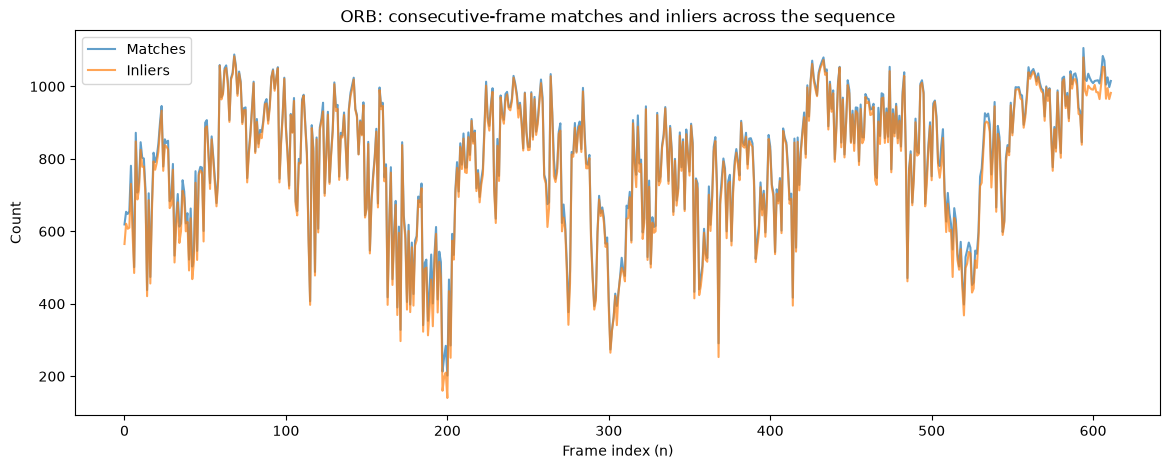

In [6]:
df_orb = pd.DataFrame(results_orb, columns=["Frame_n", "Frame_n+1", "Matches", "Inliers"])
df_orb["Inlier_Ratio"] = df_orb["Inliers"] / df_orb["Matches"].replace(0, pd.NA)

print(df_orb.head(10))

df_orb.to_csv(r"D:\ComputerVisionBenchmark\outputs\orb_consecutive_pairs.csv", index=False)
print("Saved.")

plt.figure(figsize=(14, 5))
plt.plot(df_orb["Frame_n"], df_orb["Matches"], label="Matches", alpha=0.7)
plt.plot(df_orb["Frame_n"], df_orb["Inliers"], label="Inliers", alpha=0.7)
plt.xlabel("Frame index (n)")
plt.ylabel("Count")
plt.title("ORB: consecutive-frame matches and inliers across the sequence")
plt.legend()
plt.show()

In [7]:
print("Overall avg matches:", df_orb["Matches"].mean())
print("Overall avg inliers:", df_orb["Inliers"].mean())
print("Overall avg inlier ratio:", df_orb["Inlier_Ratio"].mean())

Overall avg matches: 793.5359477124183
Overall avg inliers: 779.2026143790849
Overall avg inlier ratio: 0.9781270974005002


In [8]:
print("SIFT: avg matches 483, avg inliers 453, avg ratio 0.927")
print("ORB: avg matches", df_orb["Matches"].mean(), ", avg inliers", df_orb["Inliers"].mean(), ", avg ratio", df_orb["Inlier_Ratio"].mean())

SIFT: avg matches 483, avg inliers 453, avg ratio 0.927
ORB: avg matches 793.5359477124183 , avg inliers 779.2026143790849 , avg ratio 0.9781270974005002
